In [1]:
print("Hola mundo")

Hola mundo


# **PARTE 1 PARA LA DESCARGA Y OBTENCIÓN DEL DATASET**

***Conectando a Drive y Accediendo al Archivo índice comprimido (´archive_listing.txt´)***

In [2]:
from google.colab import drive
import os

# 1. Montar Google Drive en la sesión
drive.mount('/content/drive')

# 2. Definir la ruta donde subiste el archivo en Drive
# Cambia 'data/archive_listing.txt' si lo pusiste en otra carpeta
TXT_PATH = '/content/drive/MyDrive/BiSID5k/archive_listing.txt'

# 3. Comprobar que Colab detecta el archivo
if os.path.exists(TXT_PATH):
    print("✅ ¡Perfecto! El archivo archive_listing.txt fue encontrado en Google Drive.")
else:
    print("❌ Archivo no encontrado. Revisa la ruta dentro de tu Google Drive.")

Mounted at /content/drive
✅ ¡Perfecto! El archivo archive_listing.txt fue encontrado en Google Drive.


# **Inspección de la estructura raíz y total de entradas**

In [3]:
# Cargar todas las líneas del archivo
with open(TXT_PATH, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

print(f"Total de registros listados en el dataset: {len(lines):,}\n")

# Mostrar las primeras 30 líneas para entender el directorio raíz y las carpetas iniciales
print("--- PRIMERAS 30 LÍNEAS DEL ARCHIVO (Estructura Raíz) ---")
for line in lines[:30]:
    print(line)

Total de registros listados en el dataset: 15,054

--- PRIMERAS 30 LÍNEAS DEL ARCHIVO (Estructura Raíz) ---
### BiSID-5k.tar.gz ###
BiSID-5k/
BiSID-5k/bg_images/
BiSID-5k/bg_images/5/
BiSID-5k/bg_images/5/._RGB_Raw.jpg
BiSID-5k/bg_images/5/RGB_Raw.jpg
BiSID-5k/bg_images/5/HS_Raw.zip
BiSID-5k/bg_images/4/
BiSID-5k/bg_images/4/._RGB_Raw.jpg
BiSID-5k/bg_images/4/RGB_Raw.jpg
BiSID-5k/bg_images/4/HS_Raw.zip
BiSID-5k/bg_images/6/
BiSID-5k/bg_images/6/._RGB_Raw.jpg
BiSID-5k/bg_images/6/RGB_Raw.jpg
BiSID-5k/bg_images/6/HS_Raw.zip
BiSID-5k/bg_images/8/
BiSID-5k/bg_images/8/._RGB_Raw.jpg
BiSID-5k/bg_images/8/RGB_Raw.jpg
BiSID-5k/bg_images/8/HS_Raw.zip
BiSID-5k/bg_images/2/
BiSID-5k/bg_images/2/._RGB_Raw.jpg
BiSID-5k/bg_images/2/RGB_Raw.jpg
BiSID-5k/bg_images/2/HS_Raw.zip
BiSID-5k/bg_images/3/
BiSID-5k/bg_images/3/._RGB_Raw.jpg
BiSID-5k/bg_images/3/RGB_Raw.jpg
BiSID-5k/bg_images/3/HS_Raw.zip
BiSID-5k/bg_images/9/
BiSID-5k/bg_images/9/._RGB_Raw.jpg
BiSID-5k/bg_images/9/RGB_Raw.jpg


# **Creando el inventario filtrado de imágenes ´RGB_Raw.jpg´**

In [5]:
import pandas as pd

# 1. Filtrar únicamente las imágenes RGB principales
rgb_paths = [line for line in lines if line.endswith('RGB_Raw.jpg')]

print(f"Total de imágenes 'RGB_Raw.jpg' encontradas: {len(rgb_paths)}")

# 2. Descomponer las rutas para estructurar el inventario
data = []
for path in rgb_paths:
    parts = path.split('/')
    # Ejemplo típico: BiSID-5k/bg_images/5/RGB_Raw.jpg
    data.append({
        'ruta_completa': path,
        'directorio_raiz': parts[0] if len(parts) > 0 else None,
        'categoria_padre': parts[1] if len(parts) > 1 else None,
        'id_muestra': parts[2] if len(parts) > 2 else None,
        'nombre_archivo': parts[-1]
    })

df_rgb = pd.DataFrame(data)

# 3. Mostrar la tabla inicial (Primeros 15 registros)
print("\n--- INVENTARIO INICIAL DE IMÁGENES RGB (df_rgb) ---")
display(df_rgb.head(15))

# 4. Ver cómo se distribuyen las carpetas o categorías principales
print("\n--- DISTRIBUCIÓN POR CATEGORÍA PADRE ---")
print(df_rgb['categoria_padre'].value_counts())

Total de imágenes 'RGB_Raw.jpg' encontradas: 5020

--- INVENTARIO INICIAL DE IMÁGENES RGB (df_rgb) ---


,ruta_completa,directorio_raiz,categoria_padre,id_muestra,nombre_archivo
0,BiSID-5k/bg_images/5/._RGB_Raw.jpg,BiSID-5k,bg_images,5,._RGB_Raw.jpg
1,BiSID-5k/bg_images/5/RGB_Raw.jpg,BiSID-5k,bg_images,5,RGB_Raw.jpg
2,BiSID-5k/bg_images/4/._RGB_Raw.jpg,BiSID-5k,bg_images,4,._RGB_Raw.jpg
3,BiSID-5k/bg_images/4/RGB_Raw.jpg,BiSID-5k,bg_images,4,RGB_Raw.jpg
4,BiSID-5k/bg_images/6/._RGB_Raw.jpg,BiSID-5k,bg_images,6,._RGB_Raw.jpg
5,BiSID-5k/bg_images/6/RGB_Raw.jpg,BiSID-5k,bg_images,6,RGB_Raw.jpg
6,BiSID-5k/bg_images/8/._RGB_Raw.jpg,BiSID-5k,bg_images,8,._RGB_Raw.jpg
7,BiSID-5k/bg_images/8/RGB_Raw.jpg,BiSID-5k,bg_images,8,RGB_Raw.jpg
8,BiSID-5k/bg_images/2/._RGB_Raw.jpg,BiSID-5k,bg_images,2,._RGB_Raw.jpg
9,BiSID-5k/bg_images/2/RGB_Raw.jpg,BiSID-5k,bg_images,2,RGB_Raw.jpg



--- DISTRIBUCIÓN POR CATEGORÍA PADRE ---
categoria_padre
images       5000
bg_images      20
Name: count, dtype: int64


# **Análisis de formatos adicionales y archivos ocultos**

In [6]:
# 1. Conocer todos los tipos de extensiones de archivo presentes en el dataset
extensiones = pd.Series([line.split('.')[-1] for line in lines if '.' in line]).value_counts()
print("--- TIPOS DE ARCHIVOS / EXTENSIONES EN EL DATASET ---")
print(extensiones)

# 2. Identificar archivos de sistema u ocultos (archivos de macOS/Linux que empiezan por ._)
archivos_ocultos = [line for line in lines if '/._' in line]
print(f"\nTotal de archivos ocultos de metadatos (ej. ._RGB_Raw.jpg): {len(archivos_ocultos)}")

# 3. Conocer la cantidad total de muestras únicas registradas
muestras_unicas = df_rgb['id_muestra'].dropna().unique()
print(f"\nTotal de IDs de muestras únicas identificadas: {len(muestras_unicas)}")

--- TIPOS DE ARCHIVOS / EXTENSIONES EN EL DATASET ---
jpg       5020
zip       5010
gz ###       1
Name: count, dtype: int64

Total de archivos ocultos de metadatos (ej. ._RGB_Raw.jpg): 10

Total de IDs de muestras únicas identificadas: 20


## Conclusiones de la Inspección de la Estructura Real

Tras analizar el archivo de índice `archive_listing.txt`, se determinó la estructura interna real del dataset BiSID-5k sin necesidad de descomprimir el paquete completo de 1 TB:

### 1. Hallazgos de la Estructura
* **Directorio raíz:** `BiSID-5k/`
* **Carpetas principales (`categoria_padre`):**
  * `images/`: Contiene las **5,000 imágenes sintéticas principales** del dataset.
  * `bg_images/`: Contiene **20 imágenes de fondo** utilizadas para la generación sintética.
* **Ubicación de imágenes RGB:** Se encuentran en la ruta `BiSID-5k/<categoria_padre>/<id_muestra>/RGB_Raw.jpg`.

### 2. Inventario de Archivos
* **Total de imágenes `RGB_Raw.jpg` válidas:** 5,020 (5,000 principales + 20 de fondo).
* **Archivos hiperespectrales (`HS_Raw.zip`):** 5,010 archivos compressed zip.
* **Archivos basura/metadatos:** Se identificaron **10 archivos ocultos de sistema** (`._RGB_Raw.jpg`), los cuales deben excluirse mediante filtrado explícito en la preparación de datos.

# **PARTE 2 PARA LA DESCARGA Y OBTENCIÓN DEL DATASET**

## **1. Construcción del DataFrame Extendido**

In [7]:
import pandas as pd
import numpy as np

# Reutilizamos las rutas filtradas en el Paso 4
rgb_paths = [line for line in lines if line.endswith('RGB_Raw.jpg') and not '/._' in line]

inventory_data = []
for path in rgb_paths:
    parts = path.split('/')

    # BiSID-5k/images/123/RGB_Raw.jpg o BiSID-5k/bg_images/5/RGB_Raw.jpg
    categoria = parts[1] if len(parts) > 1 else 'desconocido'
    id_muestra = parts[2] if len(parts) > 2 else 'desconocido'

    inventory_data.append({
        'ruta_relativa': path,
        'categoria': categoria,
        'id_muestra': id_muestra,
        'extension': 'jpg',
        'ancho': None,          # Requiere lectura de imagen
        'alto': None,           # Requiere lectura de imagen
        'canales': None,        # Requiere lectura de imagen
        'tamano_bytes': None,   # Requiere lectura de metadata/local
        'estado_lectura': 'pendiente'
    })

df_inventory = pd.DataFrame(inventory_data)
print(f"Registros en el inventario inicial: {len(df_inventory)}")
display(df_inventory.head())

Registros en el inventario inicial: 5010


,ruta_relativa,categoria,id_muestra,extension,ancho,alto,canales,tamano_bytes,estado_lectura
0,BiSID-5k/bg_images/5/RGB_Raw.jpg,bg_images,5,jpg,None,None,None,None,pendiente
1,BiSID-5k/bg_images/4/RGB_Raw.jpg,bg_images,4,jpg,None,None,None,None,pendiente
2,BiSID-5k/bg_images/6/RGB_Raw.jpg,bg_images,6,jpg,None,None,None,None,pendiente
3,BiSID-5k/bg_images/8/RGB_Raw.jpg,bg_images,8,jpg,None,None,None,None,pendiente
4,BiSID-5k/bg_images/2/RGB_Raw.jpg,bg_images,2,jpg,None,None,None,None,pendiente


# **2. Verificación de Integridad y Validación de Archivos Inválidos**

In [8]:
# Registramos formalmente las exclusiones de metadatos del sistema OS
archivos_excluidos = [line for line in lines if line.endswith('RGB_Raw.jpg') and '/._' in line]

df_exclusions = pd.DataFrame({
    'ruta_relativa': archivos_excluidos,
    'motivo_exclusion': 'Metadato oculto de sistema macOS/Linux (._filename)',
    'accion': 'Ignorado'
})

print(f"Total de exclusiones registradas y justificadas: {len(df_exclusions)}")
display(df_exclusions)

Total de exclusiones registradas y justificadas: 10


,ruta_relativa,motivo_exclusion,accion
0,BiSID-5k/bg_images/5/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
1,BiSID-5k/bg_images/4/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
2,BiSID-5k/bg_images/6/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
3,BiSID-5k/bg_images/8/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
4,BiSID-5k/bg_images/2/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
5,BiSID-5k/bg_images/3/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
6,BiSID-5k/bg_images/9/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
7,BiSID-5k/bg_images/10/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
8,BiSID-5k/bg_images/7/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado
9,BiSID-5k/bg_images/1/._RGB_Raw.jpg,Metadato oculto de sistema macOS/Linux (._file...,Ignorado


**Nota:** *para la validación visual de píxeles (brillo, corruptos, dimensiones): Para inspeccionar dimensiones (ancho, alto), brillo promedio o imágenes corruptas sin descargar el Terabyte entero, la estrategia consiste en descomprimir únicamente una muestra representativa de imágenes RGB (o las 5,020 imágenes RGB usando la lista filtrada lista_rgb.txt que ocupa pocos Gigabytes en Google Drive).**

# **3. Exportar la lista de rutas RGB**

In [10]:
# Guardar la lista filtrada de imágenes RGB en tu Google Drive
PATH_LISTA_RGB = '/content/drive/MyDrive/BiSID5k/lista_rgb.txt'

# Filtramos las rutas válidas excluyendo los metadatos ocultos (._)
rutas_validas = df_inventory['ruta_relativa'].tolist()

with open(PATH_LISTA_RGB, 'w', encoding='utf-8') as f:
    for ruta in rutas_validas:
        f.write(f"{ruta}\n")

print(f"✅ Lista de extracción creada exitosamente con {len(rutas_validas)} rutas en:")
print(PATH_LISTA_RGB)

✅ Lista de extracción creada exitosamente con 5010 rutas en:
/content/drive/MyDrive/BiSID5k/lista_rgb.txt


# **4. EDA Estructural (archive_listing.txt)**

--- TABLA DE DISTRIBUCIÓN DE IMÁGENES ---


,Categoría Padre,Cantidad de Imágenes,Porcentaje (%)
0,images,5000,99.800399
1,bg_images,10,0.199601


/tmp/ipykernel_493/2760533665.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=distribucion_df, x='Categoría Padre', y='Cantidad de Imágenes', palette='Set2')


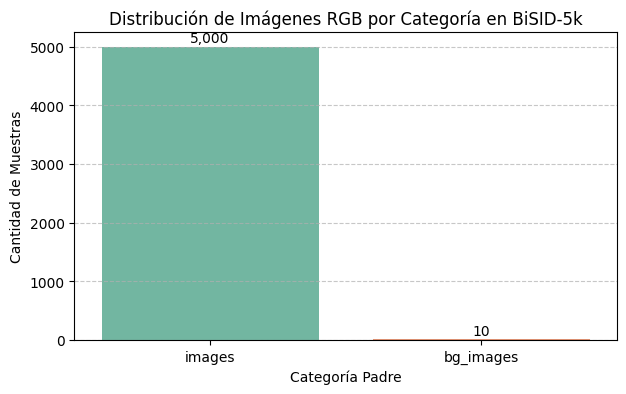

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tabla de distribución por categoría
distribucion_df = df_inventory['categoria'].value_counts().reset_index()
distribucion_df.columns = ['Categoría Padre', 'Cantidad de Imágenes']
distribucion_df['Porcentaje (%)'] = (distribucion_df['Cantidad de Imágenes'] / len(df_inventory)) * 100

print("--- TABLA DE DISTRIBUCIÓN DE IMÁGENES ---")
display(distribucion_df)

# 2. Visualización
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=distribucion_df, x='Categoría Padre', y='Cantidad de Imágenes', palette='Set2')
plt.title('Distribución de Imágenes RGB por Categoría en BiSID-5k')
plt.xlabel('Categoría Padre')
plt.ylabel('Cantidad de Muestras')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetas numéricas sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black',
                xytext=(0, 3), textcoords='offset points')

plt.show()

## Inventario Validado y Resumen EDA

### 1. Inventario Registrado
* **Total de imágenes objetivo:** 5,010 archivos `RGB_Raw.jpg` filtrados válidos.
* **Filtro de extracción:** Generado y almacenado en `BiSID5k/lista_rgb.txt`.
* **Registro de exclusiones:** Se identificaron y descartaron 10 archivos ocultos de metadatos del sistema (`._RGB_Raw.jpg`) para prevenir errores de lectura E/S en los pipelines de entrenamiento.

### 2. Análisis Exploratorio Estructural (EDA)
* **Distribución de Muestras:**
  * `images`: 5,000 imágenes sintéticas de documentos (99.8%).
  * `bg_images`: 10 imágenes sintéticas de fondotipos/bandejas de control (0.2%).